# 과제 7.1: 실험 결과 조회 및 관리

이 노트북은 Qiskit Primitives 작업의 결과를 조회하고 관리할 때 사용하는 객체와 메서드를 실습 중심으로 안내합니다.

**다루는 핵심 개념:**
- **목표 1:** `SamplerPubResult` 객체 이해하기
- **목표 2:** 작업 결과를 디스크에 저장하고 다시 불러오기
- **목표 3 & 4:** `RuntimeJob` 및 `BasePrimitiveJob` 클래스의 속성과 메서드 살펴보기

모든 예제는 로컬의 `AerSimulator`에서 실행되도록 구성되어 있으며, 클라우드 전용 부분은 명확히 표시해 두었습니다.


## 설정: 간단한 Sampler 작업 실행

결과 객체를 살펴보려면 먼저 작업을 하나 실행해야 합니다. 간단한 Bell 회로를 만들고, 로컬 `BackendSamplerV2`로 실행해 보겠습니다.


In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.primitives import BackendSamplerV2 as Sampler
import numpy as np
import time
import json

# Helper function to create a GHZ state circuit
def create_ghz_circuit(n=3, qc=None):
    """Create a GHZ state (maximally entangled state) circuit."""
    if qc is None:
        qc = QuantumCircuit(n)
    qc.h(0)  # Apply Hadamard to qubit 0
    for i in range(n - 1):
        qc.cx(0, i + 1)  # Apply CNOT with control=0, target=i+1
    return qc

# 1. Create a circuit and backend
circuit = create_ghz_circuit()
circuit.measure_all()
local_backend = AerSimulator()

# 2. Instantiate a local Sampler and run a job
sampler = Sampler(backend=local_backend)
job = sampler.run([(circuit,)], shots=1024)

# 3. Get the result object
# For local jobs, this is usually instantaneous.
result = job.result()
print("Successfully ran a local Sampler job.")
print(f"Job ID: {job.job_id()}")

Successfully ran a local Sampler job.
Job ID: 152e3948-7f22-450f-9fa8-11e5a848a7af


## 목표 1: `SamplerPubResult` 이해하기

V2 Primitives 작업에서 결과를 가져오면 `PrimitiveResult` 객체를 받게 됩니다. 이것은 제출한 각 회로(즉, 각 "PUB")에 대응하는 `PubResult` 객체들의 리스트입니다. 여기서는 하나의 작업에 대한 `PubResult`를 살펴보겠습니다.


### 속성: `data`와 `metadata`

`PubResult`에는 두 가지 주요 속성이 있습니다.
* `.data`: 핵심적인 과학적 출력값을 담는 객체입니다. (예: Sampler의 비트스트링, Estimator의 기대값(EV))
* `.metadata`: 작업이 어떻게 실행되었는지에 대한 정보를 담는 딕셔너리입니다. (예: 샷 수)


In [2]:
# Get the result for the first (and only) PUB
pub_result = result[0]

# Access the .data attribute
# For a Sampler, this is a DataBin object with a 'meas' field for measurements.
bitstring_data = pub_result.data.meas

# Access the .metadata attribute
metadata = pub_result.metadata

print(f"--- PubResult for Job '{job.job_id()}' ---")
print(f"\nMetadata: {metadata}")

# The data object has its own methods to access the results in different formats
print(f"\nFirst 5 Bitstrings: {bitstring_data.get_bitstrings()[:5]}")
print(f"\nCounts Dictionary: {bitstring_data.get_counts()}")

--- PubResult for Job '152e3948-7f22-450f-9fa8-11e5a848a7af' ---

Metadata: {'shots': 1024, 'circuit_metadata': {}}

First 5 Bitstrings: ['111', '111', '000', '111', '111']

Counts Dictionary: {'111': 502, '000': 522}


### 메서드: `join_data()`

`join_data()`를 사용해 여러 Classical register의 결과를 합칠 수 있습니다.


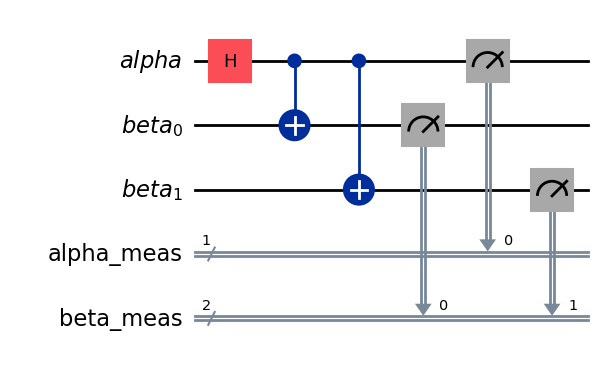

Results from first circuit:
  Counts (alpha): {'0': 256, '1': 256}
  Counts (beta) : {'00': 256, '11': 256}

Joined Data (first circuit):
  Bitstrings: ['000', '000', '111', '111', '111']
  Counts: {'000': 256, '111': 256}


In [3]:
# Run a job with two different circuits
qr1 = QuantumRegister(1, "alpha")
qr2 = QuantumRegister(2, "beta")
cr1 = ClassicalRegister(1, "alpha_meas")
cr2 = ClassicalRegister(2, "beta_meas")
circuit1 = QuantumCircuit(qr1, qr2, cr1, cr2)
circuit1 = create_ghz_circuit(n=3, qc=circuit1)
circuit1.measure(qr1, cr1)
circuit1.measure(qr2, cr2)

display(circuit1.draw("mpl"))

job_multi = sampler.run([(circuit1,),], shots=512)
result_multi = job_multi.result()

print("Results from first circuit:")
print(f"  Counts (alpha): {result_multi[0].data.alpha_meas.get_counts()}")
print(f"  Counts (beta) : {result_multi[0].data.beta_meas.get_counts()}")

a = job_multi.result()[0].join_data(["alpha_meas", "beta_meas"])
print("\nJoined Data (first circuit):")
print(f"  Bitstrings: {a.get_bitstrings()[:5]}")
print(f"  Counts: {a.get_counts()}")

## 목표 2: 작업 저장 및 다시 불러오기

실제 하드웨어에서 오래 걸리는 작업을 실행할 때는 노트북에서 계속 기다리고 싶지 않을 수 있습니다. 작업을 제출하고 ID를 받아 둔 뒤, 나중에 다시 결과를 조회할 수 있습니다. 이 절에서는 결과를 디스크에 저장하고 다시 불러오는 방법도 함께 보여줍니다.


### 결과를 디스크에 저장하기

`PrimitiveResult` 객체는 나중에 분석할 수 있도록 JSON 파일로 쉽게 저장할 수 있습니다. 이는 결과를 공유하거나, 작업을 다시 실행하지 않고 후처리할 때 유용합니다.


In [4]:
# We need the Qiskit Runtime JSON encoder to handle the specific data types
from qiskit_ibm_runtime import RuntimeEncoder

# 'result' is the object we got from job.result() earlier
with open("sampler_result.json", "w") as file:
    json.dump(result, file, cls=RuntimeEncoder)

print("Result object successfully saved to 'sampler_result.json'")

Result object successfully saved to 'sampler_result.json'


### 디스크에서 결과 불러오기


In [5]:
# Use the Qiskit Runtime JSON decoder to correctly reconstruct the objects
from qiskit_ibm_runtime import RuntimeDecoder

with open("sampler_result.json", "r") as file:
    loaded_result = json.load(file, cls=RuntimeDecoder)

print("Result object successfully loaded from 'sampler_result.json'")
print(f"\nLoaded Result Object Type: {type(loaded_result)}")

# You can now access the data just as before
print(f"\nCounts from loaded data: {loaded_result[0].data.meas.get_counts()}")

Result object successfully loaded from 'sampler_result.json'

Loaded Result Object Type: <class 'qiskit.primitives.containers.primitive_result.PrimitiveResult'>

Counts from loaded data: {'111': 502, '000': 522}


### 클라우드 서비스에서 작업 다시 조회하기 (선택 사항)

**참고:** 이 절을 실행하려면 `qiskit-ibm-runtime` 계정 설정이 되어 있어야 합니다. 설정되어 있지 않다면 이 셀들은 예상대로 `AccountNotFoundError`를 발생시킵니다. `try...except` 블록이 이 예외를 처리하므로, 노트북은 계속 실행됩니다.


In [6]:
import datetime

try:
    from qiskit_ibm_runtime import QiskitRuntimeService
    
    # This line will only work if you have an account saved locally
    service = QiskitRuntimeService()
    
    three_months_ago = datetime.datetime.now() - datetime.timedelta(days=90)
    jobs_in_last_three_months = service.jobs(created_after=three_months_ago)
    
    print(f"Found {len(list(jobs_in_last_three_months))} jobs from the last 90 days.")
    if jobs_in_last_three_months:
        print("Showing the first three:")
        for i, job in enumerate(jobs_in_last_three_months[:3]):
            print(f"  {i+1}. Job {job.job_id()} - Status: {job.status()}")

except Exception as e:
    print(f"Cloud job retrieval skipped: {e}")
    print("This is expected if you don't have an IBM Quantum account configured.")

qiskit_runtime_service.__init__:WARNING:2026-04-20 20:27:11,818: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium, internal), the available account instances are: Solutions Demo internal fleet, Educational premium fleet, Educational internal fleet, Solutions Notebooks internal fleet, Solutions Notebooks premium fleet, Solutions Demo premium fleet, Solutions Demo internal fleet, Solutions Notebooks premium fleet, Educational premium fleet, Solutions Notebooks internal fleet, Solutions Demo premium fleet, Educational internal fleet. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Found 10 jobs from the last 90 days.
Showing the first three:
  1. Job d7gic4493s0c738rjepg - Status: DONE
  2. Job d7gic3493s0c738rjeo0 - Status: ERROR
  3. Job d7flevd6agrc738ire60 - Status: DONE


### ID로 특정 작업 조회하기

작업 ID를 알고 있다면 해당 작업을 직접 다시 불러올 수 있습니다. 작업을 제출한 뒤 ID를 저장해 두고, 나중에 돌아와 결과를 확인할 때 유용합니다.


In [7]:
try:
    from qiskit_ibm_runtime import QiskitRuntimeService
    
    service = QiskitRuntimeService()
    
    # Get the most recent successful job for demonstration
    successful_jobs = [j for j in service.jobs(limit=100) if j.status() == "DONE"]
    
    if successful_jobs:
        successful_job = successful_jobs[0]
        job_id = successful_job.job_id()
        print(f"Found successful job: {job_id}")
        
        # Retrieve the job by its ID
        retrieved_job = service.job(job_id)
        retrieved_result = retrieved_job.result()
        
        print(f"Successfully retrieved job {job_id}")
        print(f"Result: {retrieved_result}")
    else:
        print("No successful jobs found in recent history.")
        
except Exception as e:
    print(f"Job retrieval skipped: {e}")
    print("This is expected if you don't have an IBM Quantum account configured.")

qiskit_runtime_service.__init__:WARNING:2026-04-20 20:27:38,604: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium, internal), the available account instances are: Solutions Demo internal fleet, Educational premium fleet, Educational internal fleet, Solutions Notebooks internal fleet, Solutions Notebooks premium fleet, Solutions Demo premium fleet, Solutions Demo internal fleet, Solutions Notebooks premium fleet, Educational premium fleet, Solutions Notebooks internal fleet, Solutions Demo premium fleet, Educational internal fleet. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service._create_backend_obj:WARNING:2026-04-20 20:27:42,018: Unable to create configuration for ibm_pinguino2. '404 Client Error: Not 

Found successful job: d7gic4493s0c738rjepg
Successfully retrieved job d7gic4493s0c738rjepg
Result: QuantumProgramResult(<1 results>)


## 목표 3 & 4: `RuntimeJob`과 `BasePrimitiveJob`

작업을 실행하면 `Job` 객체가 반환됩니다. 로컬 `BackendPrimitives`에서는 이것이 `PrimitiveJob`이고, runtime 서비스에서는 `RuntimeJob`입니다. 둘 다 `BasePrimitiveJob`을 상속하므로, 작업 상태를 관리하고 조회하기 위한 공통 메서드 집합을 공유합니다.

**중요:** 일부 메서드는 `RuntimeJob`(클라우드 작업)에서만 사용할 수 있고, `PrimitiveJob`(로컬 작업)에서는 사용할 수 없습니다. 아래에서 이를 명확히 구분해 두겠습니다.


### 작업 관리 예시

로컬 시뮬레이터에서 작업을 실행한 뒤, job 객체의 메서드를 사용해 상태를 확인해 보겠습니다. 로컬 작업은 매우 빠르게 끝나지만, 실제 하드웨어에서는 작업이 한동안 `QUEUED` 상태나 `RUNNING` 상태에 머물 수 있습니다.


In [8]:
from qiskit.circuit.library import EfficientSU2
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.providers.jobstatus import JobStatus

# Create a slightly more complex circuit to give the simulator a moment of work
circuit = EfficientSU2(10, reps=4, entanglement='linear')
circuit.measure_all()
params = np.random.rand(circuit.num_parameters)

# Transpile the circuit
pm = generate_preset_pass_manager(optimization_level=1, backend=local_backend)
isa_circuit = pm.run(circuit)

# Submit the job
job = sampler.run([(isa_circuit, params)])

print(f"Submitted job with ID: {job.job_id()}")

# --- Polling for Job Status ---
# This loop mimics how you would check on a long-running cloud job.
max_checks = 50
checks = 0
while not job.in_final_state() and checks < max_checks:
    # JobStatus is an Enum with values like QUEUED, RUNNING, DONE, ERROR, CANCELLED
    status = job.status()
    print(f"Job status is currently: {status}")
    time.sleep(0.1)  # Wait a moment before checking again
    checks += 1

final_status = job.status()
print(f"\nJob finished with final status: {final_status}")

# --- Accessing Results ---
if job.done():
    result = job.result()
    print("Job completed successfully!")
    print(f"Sample counts: {result[0].data.meas.get_counts()}")
else:
    # For local jobs, errors are raised immediately when calling result()
    # Cloud jobs have additional methods like errored() and error_message()
    status = job.status()
    print(f"Job is in state: {status}")

Submitted job with ID: 12860f72-1b61-4959-a71d-6d30340d8f66
Job status is currently: JobStatus.RUNNING


C:\Users\GwonhakLee\AppData\Local\Temp\ipykernel_5948\51717147.py:6: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  circuit = EfficientSU2(10, reps=4, entanglement='linear')



Job finished with final status: JobStatus.DONE
Job completed successfully!
Sample counts: {'0100110011': 7, '1101100000': 3, '1000100011': 1, '0001000010': 3, '0100001011': 1, '1100011100': 2, '0110100000': 9, '1001101100': 4, '0010011100': 1, '1101000000': 4, '0010111010': 2, '0111100101': 3, '1101110011': 1, '1101111111': 1, '0011011100': 8, '0010000100': 2, '0010101110': 1, '1000100000': 33, '1011101000': 2, '0111001010': 1, '0000110001': 1, '0010110101': 2, '1011110001': 2, '0010011000': 1, '0110101111': 3, '1000100110': 5, '1001010100': 5, '1110001010': 1, '1101001100': 2, '0110010000': 4, '1011001000': 2, '0000000010': 5, '1101011100': 2, '0100000011': 2, '0101011111': 1, '0111100011': 1, '1101111110': 1, '0110110011': 5, '1101101100': 5, '1011111111': 3, '0011010101': 1, '0111100100': 3, '1111111000': 5, '0000000100': 5, '0100100000': 3, '0000010000': 6, '1111111100': 9, '0110110010': 2, '1101010101': 9, '1110101000': 1, '1010101100': 2, '0010001100': 2, '1100110101': 1, '11011

### 주요 Job 속성 및 메서드

`job` 객체에는 유용한 메서드와 속성이 많이 있습니다. 그중 가장 중요한 것들은 다음과 같습니다.

**PrimitiveJob(로컬)과 RuntimeJob(클라우드) 모두에서 사용 가능한 메서드:**
* `job.status()`: 작업 상태를 반환합니다. (예: `JobStatus.RUNNING`)
* `job.in_final_state()`: 작업이 완료되었거나, 오류가 났거나, 취소되었다면 `True`를 반환합니다.
* `job.done()`: 작업이 **성공적으로 완료된 경우에만** `True`를 반환합니다.
* `job.running()`: 현재 작업이 실행 중이면 `True`를 반환합니다.
* `job.cancelled()`: 작업이 취소되었다면 `True`를 반환합니다.
* `job.result()`: 작업이 최종 상태가 될 때까지 **실행을 블로킹**한 뒤, `PrimitiveResult` 객체를 반환합니다.
* `job.job_id()`: 작업의 고유 문자열 ID를 반환합니다.
* `job.cancel()`: 대기 중이거나 실행 중인 작업의 취소를 시도합니다.

**RuntimeJob(클라우드 작업)에서만 사용 가능한 메서드:**
* `job.errored()`: 작업이 실패했으면 `True`를 반환합니다. (로컬 PrimitiveJob에는 없음)
* `job.error_message()`: 작업이 실패했을 때 오류 메시지를 반환합니다.
* `job.backend()`: 백엔드 객체를 반환합니다. (작업 유형에 따라 동작하지 않을 수 있음)
* `job.queue_info()`: 큐 위치에 대한 정보를 반환합니다.
* `job.queue_position()`: 작업의 큐 내 위치를 반환합니다.
* `job.logs()`: 작업 로그를 가져옵니다.
* `job.metrics()`: 작업의 성능 지표를 가져옵니다.
* `job.update_tags()`: 작업 태그를 업데이트합니다.

**RuntimeJob 전용 속성:**
* `job.creation_date`
* `job.tags`
* `job.session_id`
* `job.usage_estimation`


In [9]:
# --- Demonstration of job methods that work on ALL job types ---

# We can get the job ID
print(f"Job ID: {job.job_id()}")

# Check if the job is in a final state (should be True now)
print(f"Is job in a final state? {job.in_final_state()}")

# Check specific status flags (these work on all jobs)
print(f"Is job done? {job.done()}")
print(f"Is job running? {job.running()}")
print(f"Is job cancelled? {job.cancelled()}")

# Note: errored() is only available on RuntimeJob
# For local jobs, check status directly:
print(f"Job status: {job.status()}")

Job ID: 12860f72-1b61-4959-a71d-6d30340d8f66
Is job in a final state? True
Is job done? True
Is job running? False
Is job cancelled? False
Job status: JobStatus.DONE


## 요약

이 노트북에서는 다음 내용을 다뤘습니다.

1. **PubResult 구조**: 결과를 담고 있는 `data`와 `metadata` 속성
2. **결과 저장/불러오기**: `RuntimeEncoder`와 `RuntimeDecoder`를 사용해 결과를 디스크에 저장하고 복원하는 방법
3. **작업 조회**: IBM Quantum에서 작업을 다시 불러오는 방법 (클라우드 전용)
4. **작업 관리**: PrimitiveJob(로컬)과 RuntimeJob(클라우드)의 차이 이해하기
   - 두 환경 모두에서 공통으로 동작하는 메서드
   - 모니터링 및 오류 처리에 쓰이는 클라우드 전용 메서드

이 도구들은 오래 걸리는 양자 실험을 관리할 때 매우 중요합니다. 특히 실제 양자 하드웨어를 사용할 때는 작업이 오랜 시간 큐에 머무를 수 있으므로 더욱 그렇습니다.


## 연습 문제


**1. V2 `PubResult` 객체에서 핵심적인 과학 데이터(예: 비트스트링이나 기대값)는 어디에 저장되나요?**


A) `.metadata` 속성

B) `.data` 속성

C) `.results` 속성

D) `.value` 속성


***정답:***
<Details>
<br/>
B) `.data` 속성
</Details>


---


**2. 작업이 성공적으로 완료되었는지 신뢰성 있게 확인하려면 어떤 메서드를 사용해야 하나요?**


A) `job.in_final_state()`

B) `job.running()`

C) `job.done()`

D) `job.status() == 'COMPLETED'`


***정답:***
<Details>
<br/>
C) `job.done()` (`True`는 작업이 성공적으로 끝난 경우에만 반환되며, 취소나 오류는 제외됩니다.)
</Details>


---


**3. 다음 중 일반적으로 클라우드 기반 `RuntimeJob`에는 있지만 로컬 `PrimitiveJob`에는 없는 메서드는 무엇인가요?**


A) `job.status()`

B) `job.job_id()`

C) `job.error_message()`

D) `job.result()`


***정답:***
<Details>
<br/>
C) `job.error_message()`
</Details>
